In [ ]:
# CELL 1: INSTALL LIBRARIES
%%capture
!pip install imutils seaborn scikit-image albumentations

In [ ]:
import sys
!{sys.executable} -m pip install mean_average_precision

In [ ]:
# CELL 2: IMPORT LIBRARIES
import os
import cv2
import glob
import joblib
import random
import imutils
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from imutils.object_detection import non_max_suppression
from skimage.feature import hog
from skimage.transform import pyramid_gaussian

from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
# CELL 3: MOUNT GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# CELL 4: CONFIG
DATASET_TYPE='main' # demo hoặc main

if DATASET_TYPE=='demo':
    ROOT='/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/demo'
    CLASSES=['Bus','Car','Motorbike','Truck','Pickup']
else:
    ROOT='/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main'
    CLASSES=['Bus','Car','Motorbike','Truck']

# YOLOv8 STRUCTURE
TRAIN_IMG=os.path.join(ROOT,'train/images')
TRAIN_LABEL=os.path.join(ROOT,'train/labels')

VAL_IMG=os.path.join(ROOT,'valid/images')
VAL_LABEL=os.path.join(ROOT,'valid/labels')

TEST_IMG=os.path.join(ROOT,'test/images')
TEST_LABEL=os.path.join(ROOT,'test/labels')

WINDOW_SIZE=(64,64)
STEP_SIZE=16
PYRAMID_SCALE=1.5
MODEL_PATH='/content/drive/MyDrive/CS231/CS231_VehicleDetection/models/hog_svm_detector.pkl'

CLASS2IDX={c:i for i,c in enumerate(CLASSES)}
IDX2CLASS={i:c for i,c in enumerate(CLASSES)}

print(TRAIN_IMG)
print(TRAIN_LABEL)

print(os.path.exists(TRAIN_IMG))
print(os.path.exists(TRAIN_LABEL))

print(len(glob.glob(os.path.join(TRAIN_IMG,'*'))))
print(len(glob.glob(os.path.join(TRAIN_LABEL,'*'))))

/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/train/images
/content/drive/MyDrive/CS231/CS231_VehicleDetection/data/main/train/labels
True
True
800
800


In [ ]:
# CELL 5: LOAD YOLO LABEL
def load_yolo_boxes(label_path,w,h):

    boxes=[]
    labels=[]

    if not os.path.exists(label_path):
        return boxes,labels

    with open(label_path,'r') as f:
        lines=f.readlines()

    for line in lines:

        c,x,y,bw,bh=map(float,line.strip().split())

        xmin=int((x-bw/2)*w)
        ymin=int((y-bh/2)*h)
        xmax=int((x+bw/2)*w)
        ymax=int((y+bh/2)*h)

        boxes.append([xmin,ymin,xmax,ymax])
        labels.append(int(c))

    return boxes,labels

In [ ]:
# CELL 6: EXTRACT HOG FEATURE
def extract_hog(image):

    gray=cv2.cvtColor(image,cv2.COLOR_RGB2GRAY)

    feature=hog(
        gray,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        transform_sqrt=True,
        block_norm='L2-Hys'
    )

    return feature

In [ ]:
# CELL 7: CREATE POSITIVE SAMPLES
def create_positive_samples(img_dir,label_dir):

    features=[]
    labels=[]

    img_paths=sorted(glob.glob(os.path.join(img_dir,'*')))

    for img_path in tqdm(img_paths):

        image=cv2.imread(img_path)

        if image is None:
            continue

        image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

        h,w,_=image.shape

        label_path=os.path.join(
            label_dir,
            os.path.basename(img_path).replace('.jpg','.txt').replace('.png','.txt')
        )

        boxes,cls_labels=load_yolo_boxes(label_path,w,h)

        for box,label in zip(boxes,cls_labels):

            xmin,ymin,xmax,ymax=box

            crop=image[ymin:ymax,xmin:xmax]

            if crop.shape[0]==0 or crop.shape[1]==0:
                continue

            crop=cv2.resize(crop,WINDOW_SIZE)

            feature=extract_hog(crop)

            features.append(feature)
            labels.append(label)

    return features,labels

In [ ]:
# CELL 8: CREATE NEGATIVE SAMPLES
def create_negative_samples(img_dir,label_dir,max_samples=2000):

    features=[]
    labels=[]

    img_paths=sorted(glob.glob(os.path.join(img_dir,'*')))

    count=0

    for img_path in tqdm(img_paths):

        image=cv2.imread(img_path)

        if image is None:
            continue

        image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

        h,w,_=image.shape

        label_path=os.path.join(
            label_dir,
            os.path.basename(img_path).replace('.jpg','.txt').replace('.png','.txt')
        )

        gt_boxes,_=load_yolo_boxes(label_path,w,h)

        for _ in range(20):

            x=random.randint(0,w-WINDOW_SIZE[0]-1)
            y=random.randint(0,h-WINDOW_SIZE[1]-1)

            candidate=[x,y,x+WINDOW_SIZE[0],y+WINDOW_SIZE[1]]

            overlap=False

            for gt in gt_boxes:

                xx1=max(candidate[0],gt[0])
                yy1=max(candidate[1],gt[1])
                xx2=min(candidate[2],gt[2])
                yy2=min(candidate[3],gt[3])

                inter=max(0,xx2-xx1)*max(0,yy2-yy1)

                if inter>0:
                    overlap=True
                    break

            if overlap:
                continue

            crop=image[y:y+WINDOW_SIZE[1],x:x+WINDOW_SIZE[0]]

            feature=extract_hog(crop)

            features.append(feature)
            labels.append(-1)

            count+=1

            if count>=max_samples:
                return features,labels

    return features,labels

In [ ]:
   # CELL 9: CREATE TRAIN DATASET
pos_features,pos_labels=create_positive_samples(
    TRAIN_IMG,
    TRAIN_LABEL
)

neg_features,neg_labels=create_negative_samples(
    TRAIN_IMG,
    TRAIN_LABEL,
    max_samples=20000
)

X_train=np.array(pos_features+neg_features)
y_train=np.array(pos_labels+neg_labels)

print(X_train.shape)
print(y_train.shape)

100%|██████████| 800/800 [00:33<00:00, 24.17it/s]


(19515, 1764)
(19515,)


In [38]:
model=Pipeline([
    ('scaler',StandardScaler()),
    ('svm',LinearSVC( # Changed from LinearSVC to SVC
        C=1.0,
        class_weight='balanced',
        max_iter=20000, # Still good to keep high for SVC, though it might take more
    ))
])

model.fit(X_train,y_train)

print('TRAINING DONE')

TRAINING DONE


In [39]:
# CELL 11: SAVE MODEL
joblib.dump(model, MODEL_PATH)

print('MODEL SAVED')

MODEL SAVED


In [40]:
# CELL 12: LOAD MODEL
model=joblib.load(MODEL_PATH)

print('MODEL LOADED')

MODEL LOADED


In [41]:
# CELL 13: SLIDING WINDOW
def sliding_window(image,step,window_size):
    for y in range(0,image.shape[0]-window_size[1],step):
        for x in range(0,image.shape[1]-window_size[0],step):
            yield (x,y,image[y:y+window_size[1],x:x+window_size[0]])

In [42]:
# CELL 14: DETECTION FUNCTION
def detect_vehicle(image,model):

    boxes=[]
    scores=[]
    labels=[]
    scale=0

    for resized in pyramid_gaussian(image, downscale=PYRAMID_SCALE, channel_axis=-1):

        resized=(resized*255).astype(np.uint8)
        if resized.shape[0]<WINDOW_SIZE[1] or resized.shape[1]<WINDOW_SIZE[0]:
            break
        current_scale=PYRAMID_SCALE**scale
        for (x,y,window) in sliding_window(resized, STEP_SIZE, WINDOW_SIZE):

            if window.shape[0]!=WINDOW_SIZE[1] or window.shape[1]!=WINDOW_SIZE[0]:
                continue

            feature=extract_hog(window)
            pred=model.predict([feature])[0]
            if pred==-1:
                continue

            score=np.max(model.decision_function([feature]))
            if score<0.5:
                continue

            x1=int(x*current_scale)
            y1=int(y*current_scale)
            x2=int((x+WINDOW_SIZE[0])*current_scale)
            y2=int((y+WINDOW_SIZE[1])*current_scale)
            boxes.append([x1,y1,x2,y2])
            scores.append(score)
            labels.append(pred)
        scale+=1

    if len(boxes)==0:
        return [],[],[]
    boxes=np.array(boxes)
    pick=non_max_suppression(boxes, probs=np.array(scores),
 overlapThresh=0.3)
    final_boxes=[]
    final_scores=[]
    final_labels=[]
    for p in pick:
        for i,b in enumerate(boxes):
            if np.array_equal(p,b):
                final_boxes.append(b)
                final_scores.append(scores[i])
                final_labels.append(labels[i])

    return final_boxes,final_scores,final_labels

## Model Evaluation

To evaluate the object detection model, we will calculate several metrics including Intersection over Union (IoU), Precision, Recall, mAP (mean Average Precision), Confusion Matrix, Average Inference Time, and Frames Per Second (FPS).

First, let's define a helper function to compute the IoU between two bounding boxes.

In [43]:
# CELL 15: CALCULATE IOU
def calculate_iou(boxA, boxB):
    # determine the (x, y)-coordinates of the intersection rectangle
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    # compute the area of intersection rectangle
    interArea = max(0, xB - xA + 1) * max(0, yB - yA + 1)

    # compute the area of both the prediction and ground-truth rectangles
    boxAArea = (boxA[2] - boxA[0] + 1) * (boxA[3] - boxA[1] + 1)
    boxBArea = (boxB[2] - boxB[0] + 1) * (boxB[3] - boxB[1] + 1)

    # compute the intersection over union by taking the intersection
    # area and dividing it by the sum of prediction + ground-truth
    # areas - the interesection area
    iou = interArea / float(boxAArea + boxBArea - interArea)

    # return the intersection over union value
    return iou

Next, we will set up the evaluation process by defining a function `evaluate_model` that performs detections on a given image dataset, calculates IoU, and prepares the data for computing metrics like mAP and confusion matrix. It also measures inference time.

In [44]:
# CELL 16: EVALUATE MODEL
import time
from mean_average_precision import MetricBuilder

def evaluate_model(img_dir, label_dir, model, class_map):
    all_detections = []
    all_ground_truths = []
    total_inference_time = 0
    image_count = 0

    img_paths = sorted(glob.glob(os.path.join(img_dir, '*')))
    image_id_map = {path: i for i, path in enumerate(img_paths)} # Map image paths to integer IDs

    # For Confusion Matrix
    true_labels_list = []
    pred_labels_list = []

    for img_path in tqdm(img_paths):
        image = cv2.imread(img_path)
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w, _ = image.shape

        label_path = os.path.join(
            label_dir,
            os.path.basename(img_path).replace('.jpg', '.txt').replace('.png', '.txt')
        )

        gt_boxes, gt_labels = load_yolo_boxes(label_path, w, h)
        current_image_id = image_id_map[img_path]

        start_time = time.time()
        pred_boxes, pred_scores, pred_labels = detect_vehicle(image, model)
        end_time = time.time()
        total_inference_time += (end_time - start_time)
        image_count += 1

        # Prepare for mAP calculation, ensuring correct data types
        for gt_box, gt_label in zip(gt_boxes, gt_labels):
            all_ground_truths.append([
                current_image_id, int(gt_label), float(gt_box[0]), float(gt_box[1]), float(gt_box[2]), float(gt_box[3])
            ])
        for pred_box, pred_score, pred_label in zip(pred_boxes, pred_scores, pred_labels):
            all_detections.append([
                current_image_id, int(pred_label), float(pred_score), float(pred_box[0]), float(pred_box[1]), float(pred_box[2]), float(pred_box[3])
            ])

        # Prepare for Confusion Matrix
        current_image_true_labels = []
        current_image_pred_labels = []

        matched_gt_indices = set()
        matched_pred_indices = set()

        # Match GTs with predictions
        for i, gt_box in enumerate(gt_boxes):
            best_iou = 0
            best_pred_match_idx = -1
            for j, pred_box in enumerate(pred_boxes):
                iou = calculate_iou(gt_box, pred_box)
                if iou > best_iou and iou >= 0.5: # IoU threshold for a match
                    best_iou = iou
                    best_pred_match_idx = j

            if best_pred_match_idx != -1:
                # True Positive
                current_image_true_labels.append(gt_labels[i])
                current_image_pred_labels.append(pred_labels[best_pred_match_idx])
                matched_gt_indices.add(i)
                matched_pred_indices.add(best_pred_match_idx)

        # False Negatives (GTs not matched)
        for i in range(len(gt_boxes)):
            if i not in matched_gt_indices:
                current_image_true_labels.append(gt_labels[i])
                current_image_pred_labels.append(len(CLASSES)) # Assign to a 'No Detection' class

        # False Positives (Predictions not matched)
        for j in range(len(pred_boxes)):
            if j not in matched_pred_indices:
                current_image_true_labels.append(len(CLASSES)) # Assign a 'Background' or 'No GT' class
                current_image_pred_labels.append(pred_labels[j])

        true_labels_list.extend(current_image_true_labels)
        pred_labels_list.extend(current_image_pred_labels)

    avg_inference_time = total_inference_time / image_count if image_count > 0 else 0
    fps = 1 / avg_inference_time if avg_inference_time > 0 else 0

    # Convert lists to numpy arrays for mAP library, ensuring float32 type
    all_detections = np.array(all_detections, dtype=np.float32)
    all_ground_truths = np.array(all_ground_truths, dtype=np.float32)

    return all_detections, all_ground_truths, avg_inference_time, fps, true_labels_list, pred_labels_list

Now, we will run the evaluation on the test dataset and compute the metrics.

In [45]:
# CELL 17: RUN EVALUATION AND COMPUTE METRICS

# Evaluate the model on the test dataset
all_detections, all_ground_truths, avg_inference_time, fps, true_labels_for_cm, pred_labels_for_cm = evaluate_model(
    TEST_IMG, TEST_LABEL, model, CLASS2IDX
)



100%|██████████| 100/100 [09:53<00:00,  5.94s/it]



--- Confusion Matrix ---


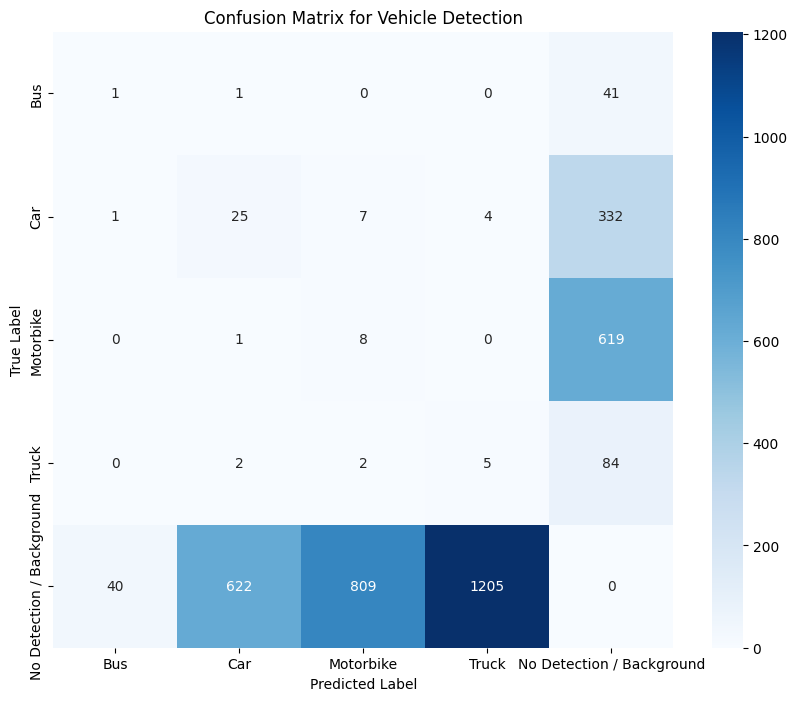

In [47]:
# Generate Confusion Matrix using the lists returned by evaluate_model

# Define labels for the confusion matrix, including a 'No Detection/Background' category
cm_labels = list(range(len(CLASSES))) + [len(CLASSES)]
cm_display_labels = CLASSES + ['No Detection / Background']

# Ensure the lists are not empty before creating CM
if len(true_labels_for_cm) > 0 and len(pred_labels_for_cm) > 0:
    # `labels` parameter in `confusion_matrix` ensures all classes are included, even if no samples exist for them
    cm = confusion_matrix(true_labels_for_cm, pred_labels_for_cm, labels=cm_labels)

    print("\n--- Confusion Matrix ---")
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=cm_display_labels, yticklabels=cm_display_labels
    )
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix for Vehicle Detection')
    plt.show()
else:
    print("\n--- Confusion Matrix ---")
    print("No data available to generate confusion matrix.")

In [50]:
import numpy as np
# Initialize MetricBuilder for mAP calculation
metric_fn = MetricBuilder.build_evaluation_metric(
    "map_2d",
    async_mode=False, # Changed to False to avoid multiprocessing assertion errors
    num_classes=len(CLASSES)
)

# Add ground truths and detections only if data is present
if len(all_detections) > 0 and len(all_ground_truths) > 0:
    # Transform all_detections to expected format: [xmin, ymin, xmax, ymax, class_id, confidence]
    # Original format: [image_id, class_id, confidence, xmin, ymin, xmax, ymax]
    all_detections_for_map = all_detections[:, [3, 4, 5, 6, 1, 2]]

    # Transform all_ground_truths to expected format: [xmin, ymin, xmax, ymax, class_id, difficult, crowd]
    # Original format: [image_id, class_id, xmin, ymin, xmax, ymax]
    gt_coords_class = all_ground_truths[:, [2, 3, 4, 5, 1]]
    difficult_crowd_flags = np.zeros((all_ground_truths.shape[0], 2), dtype=all_ground_truths.dtype)
    all_ground_truths_for_map = np.concatenate((gt_coords_class, difficult_crowd_flags), axis=1)

    metric_fn.add(all_detections_for_map, all_ground_truths_for_map)

    # Compute mAP metrics
    metrics = metric_fn.value()

    # Print mAP metrics, using .get() for robustness against missing keys
    print("\n--- mAP Metrics ---")
    print(f"mAP@0.5: {metrics.get('mAP', 0.0): .4f}")
    print(f"mAP@0.5:0.95: {metrics.get('mAP_50_95', 0.0): .4f}")
else:
    print("\n--- mAP Metrics ---")
    print("No detections or ground truths found for mAP calculation.")
    metrics = {} # Initialize metrics as an empty dict if no data

# Print inference time and FPS
print("\n--- Performance Metrics ---")
print(f"Average Inference Time: {avg_inference_time:.4f} seconds/image")
print(f"FPS: {fps:.2f}")

/usr/local/lib/python3.12/dist-packages/mean_average_precision/mean_average_precision_2d.py:64: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.match_table[c] = pd.concat([self.match_table[c], match_table], axis=0, join='outer')
/usr/local/lib/python3.12/dist-packages/mean_average_precision/mean_average_precision_2d.py:64: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.match_table[c] = pd.concat([self.match_table[c], match_table], axis=0, join='outer')
/usr/local/lib/python3.12/dist-packa


--- mAP Metrics ---
mAP@0.5:  0.0198
mAP@0.5:0.95:  0.0000

--- Performance Metrics ---
Average Inference Time: 5.9194 seconds/image
FPS: 0.17


### Precision and Recall

Now, let's compute and display the precision and recall for each class using the `classification_report` from `sklearn.metrics`.

In [51]:
from sklearn.metrics import classification_report

# Extend class names for the report to include 'No Detection / Background' if it was used
report_target_names = CLASSES + ['No Detection / Background']

# Ensure the lists are not empty before generating the report
if len(true_labels_for_cm) > 0 and len(pred_labels_for_cm) > 0:
    # Generate classification report
    # The labels parameter ensures all class labels are considered, even if some don't appear in the predictions.
    # The target_names parameter provides human-readable labels for the output.
    report = classification_report(
        true_labels_for_cm,
        pred_labels_for_cm,
        labels=cm_labels, # Use cm_labels to include the 'No Detection / Background' class
        target_names=report_target_names,
        zero_division=0 # Handle cases where there are no true samples for a class
    )
    print("\n--- Classification Report (Precision, Recall, F1-Score) ---")
    print(report)
else:
    print("\n--- Classification Report (Precision, Recall, F1-Score) ---")
    print("No data available to generate classification report.")


--- Classification Report (Precision, Recall, F1-Score) ---
                           precision    recall  f1-score   support

                      Bus       0.02      0.02      0.02        43
                      Car       0.04      0.07      0.05       369
                Motorbike       0.01      0.01      0.01       628
                    Truck       0.00      0.05      0.01        93
No Detection / Background       0.00      0.00      0.00      2676

                 accuracy                           0.01      3809
                macro avg       0.02      0.03      0.02      3809
             weighted avg       0.01      0.01      0.01      3809

